예제 4.5 MLP(Fashion_MNIST)

In [ ]:
# 예제 4.5 MLP Fashion_MNIST

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)  # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)    # 테스트 데이터 shape 확인

4422102/4422102 [==============================] - 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


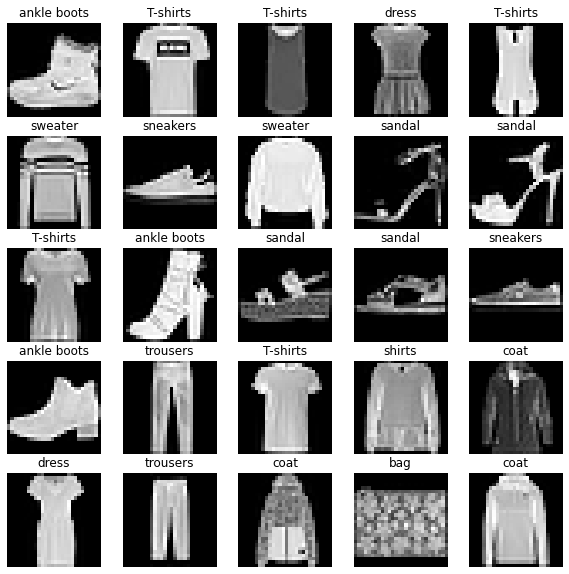

In [ ]:
# 학습 데이터 시각화(클래스명 표시)
class_names = ["T-shirts", "trousers", "sweater", "dress", "coat",
               "sandal", "shirts", "sneakers", "bag", "ankle boots"]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[int(y_train[i])])   # 레이블(클래스명) 표시
    plt.axis('off')

plt.show()

In [ ]:
# 학습 데이터/검증 데이터 분할
x_train, x_valid, y_train, y_valid = train_test_split(
   x_train, y_train, test_size=0.2, random_state=77)   # 분할 비율 0.2


print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_valid.shape, y_valid.shape)   # 검증 데이터 shape 확인

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)


In [ ]:
# 데이터 표준화
x_train = (x_train - x_train.mean()) / x_train.std()
x_valid = (x_valid - x_valid.mean()) / x_valid.std()
x_test = (x_test - x_test.mean()) / x_test.std()

In [ ]:
# 레이블 원핫 인코딩
print(y_train[0])   # 첫 번째 학습 데이터의 원래 레이블 확인

y_train = to_categorical(y_train, num_classes=10)
y_valid = to_categorical(y_valid, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train[0])   # 첫 번째 학습 데이터의 원핫 인코딩된 레이블 확인
print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_valid.shape, y_valid.shape)   # 검증 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

6
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
(48000, 28, 28) (48000, 10)
(12000, 28, 28) (12000, 10)
(10000, 28, 28) (10000, 10)


In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
x = Dense(128, activation='relu')(x)           # 은닉층1 뉴런 128개
x = Dense(64, activation='relu')(x)            # 은닉층2 뉴런 64개
outputs = Dense(10, activation='softmax')(x)   # 출력층 뉴런 10개
                                               # 출력층 활성화 함수 softmax
model = Model(inputs, outputs, name='Fashion_MNIST_MLP_model')

In [ ]:
# 모델 구조 요약
model.summary()

Model: "Fashion_MNIST_MLP_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])   # 성능 평가 지표로 정확도 사용

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, batch_size=32, epochs=30, .
                     validation_data=(x_valid, y_valid), verbose=0)

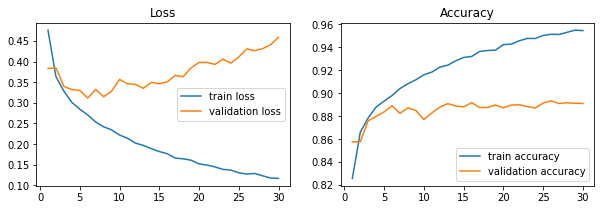

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax = axs[0]
ax.plot(range(1, len(history.history['loss']) + 1),
        history.history['loss'], label='train loss')
ax.plot(range(1, len(history.history['val_loss']) + 1),
        history.history['val_loss'], label='validation loss')
ax.set_title('Loss')
ax.legend(loc='best')

ax = axs[1]
ax.plot(range(1, len(history.history['accuracy']) + 1),
        history.history['accuracy'], label='train accuracy')
ax.plot(range(1, len(history.history['val_accuracy']) + 1),
        history.history['val_accuracy'], label='validation accuracy')
ax.set_title('Accuracy')
ax.legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)   # 테스트 데이터로 성능 평가

313/313 [==============================] - 1s 2ms/step - loss: 0.5340 - accuracy: 0.8797


[0.5339750051498413, 0.8797000050544739]

1/1 [==============================] - 0s 79ms/step
prediction:  coat  sandal  sneakers  dress  coat  trousers  sweater  sweater  bag  T-shirts  
 label:  coat  sandal  sneakers  dress  coat  trousers  sweater  coat  bag  T-shirts  

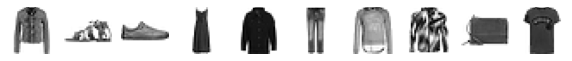

In [ ]:
# 모델 예측
x = x_test[10: 20]   # 테스트 데이터 10번째 ~ 20번째
y_pred = np.argmax(model.predict(x), axis=1)

print(f"prediction: ", end=' ')
for i in range(10):
    print(class_names[y_pred[i]], end='  ')

print(f"\n label: ", end=' ')
for i in range(10):
    print(class_names[int(np.argmax(y_test[i+10], axis=-1))], end='  ')

fig, axs = plt.subplots(1, 10, figsize=(10,10))

for i in range(10):
    axs[i].imshow(x_test[i+10], cmap='gray_r')
    axs[i].axis('off')

plt.show()

In [ ]:
# 레이블 원핫 인코딩을 정수로 변환
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

print(y_test.shape, y_pred.shape)

313/313 [==============================] - 0s 1ms/step
(10000,) (10000,)


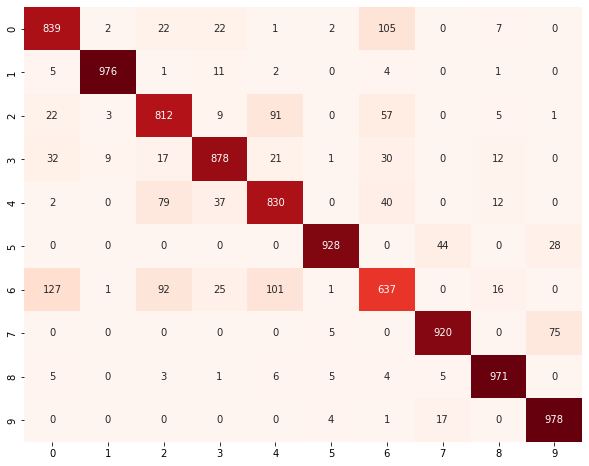

In [ ]:
# 혼동 행렬(히트맵)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred),   # 혼동 행렬
            annot=True, fmt='d', cmap='Reds', cbar=False)   # 숫자, 정수 표기
plt.show()

In [ ]:
# 혼동 행렬
print(confusion_matrix(y_test, y_pred))

# 성능 평가
print("\n", classification_report(y_test, y_pred))

[[828   1  24  25   5   2 110   0   5   0]
 [  3 981   0   9   4   0   3   0   0   0]
 [ 27   1 757  15 132   1  65   0   2   0]
 [ 28  20   8 880  34   0  26   1   3   0]
 [  2   0  50  33 835   0  79   0   1   0]
 [  0   0   0   1   0 936   0  47   1  15]
 [124   1  69  24  73   0 702   0   7   0]
 [  0   0   0   0   0   7   0 956   0  37]
 [  5   1   2   7   5   2   9   4 964   1]
 [  2   0   0   0   0   8   0  31   1 958]]

               precision    recall  f1-score   support

           0       0.81      0.83      0.82      1000
           1       0.98      0.98      0.98      1000
           2       0.83      0.76      0.79      1000
           3       0.89      0.88      0.88      1000
           4       0.77      0.83      0.80      1000
           5       0.98      0.94      0.96      1000
           6       0.71      0.70      0.70      1000
           7       0.92      0.96      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.95   